In [1]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import plotnine as pn
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

In [3]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

In [3]:
def fisher_enrichment(test_genes, background_genes, predisposition_genes):
    test_genes = set(test_genes)
    background_genes = set(background_genes)
    predisposition_genes = set(predisposition_genes)

    non_test = background_genes - test_genes

    a = len(test_genes & predisposition_genes)
    b = len(test_genes - predisposition_genes)
    c = len(non_test & predisposition_genes)
    d = len(non_test - predisposition_genes)

    # Haldane–Anscombe correction
    a_, b_, c_, d_ = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_ratio, p_val = fisher_exact([[a, b], [c, d]])

    se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    z = 1.96

    log_or = np.log(odds_ratio)
    ci_min = np.exp(log_or - z * se)
    ci_max = np.exp(log_or + z * se)

    return odds_ratio, ci_min, ci_max, p_val, a, b, c, d



def add_significance(p):
    if p <= 0.0001:
        return "****"
    elif p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"


def fisher_test(test_genes, all_genes, test_list):
    """
    Equivalent of the R fisher_test function
    """
    test_genes = set(test_genes)
    all_genes = set(all_genes)
    test_list = set(test_list)

    non_test_genes = all_genes - test_genes

    a = len(test_genes & test_list)
    b = len(test_genes - test_list)
    c = len(non_test_genes & test_list)
    d = len(non_test_genes - test_list)

    table = [[a, b], [c, d]]
    odds_ratio, p_value = fisher_exact(table)

    return odds_ratio, p_value


def fisher_test_with_ci(test_genes, all_genes, test_list, alpha=0.05):
    """
    Fisher exact test + odds ratio confidence interval
    """

    test_genes = set(test_genes)
    all_genes = set(all_genes)
    test_list = set(test_list)

    non_test_genes = all_genes - test_genes

    a = len(test_genes & test_list)
    b = len(test_genes - test_list)
    c = len(non_test_genes & test_list)
    d = len(non_test_genes - test_list)

    # avoid zero counts (same trick R uses)
    a_, b_, c_, d_ = a + 0.5, b + 0.5, c + 0.5, d + 0.5

    odds_ratio, p_value = fisher_exact([[a, b], [c, d]])

    # log(OR) CI
    se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    z = 1.96  # 95% CI

    log_or = np.log(odds_ratio)
    ci_low = np.exp(log_or - z * se)
    ci_high = np.exp(log_or + z * se)

    return odds_ratio, ci_low, ci_high, p_value


def create_enrichments(res_df, expression_direction, exp_gene):

    # choose gene set
    if expression_direction == "underexpression":
        cgc_df = cgc_tsg
    elif expression_direction in ["overexpression", "activation"]:
        cgc_df = cgc_oncogene
    elif expression_direction == "under_predisposed":
        cgc_df = dresden_dt_tsg
    elif expression_direction == "over_predisposed":
        cgc_df = dresden_dt_oncogene
    elif expression_direction == "predisposed":
        cgc_df = dresden_dt
    elif expression_direction == "activation_predisposed":
        cgc_df = dresden_dt_oncogene
    else:
        raise ValueError("Unknown expression_direction")

    print(len(cgc_df))

    # filter by zScore if present
    if "zScore" in res_df.columns:
        if expression_direction in ["underexpression", "under_predisposed"]:
            or_dn = res_df[res_df["zScore"] < 0]
        elif expression_direction in ["overexpression", "over_predisposed"]:
            or_dn = res_df[res_df["zScore"] > 0]
        else:
            or_dn = res_df.copy()
    else:
        or_dn = res_df.copy()

    # count outliers per gene
    gene_freq = (
        or_dn.groupby("geneID")
        .size()
        .reset_index(name="N")
    )

    # two categories only
    non_outliers = set(exp_gene) - set(gene_freq["geneID"])
    outliers_ge_1 = set(gene_freq.loc[gene_freq["N"] >= 1, "geneID"])

    categories = {
        "non_outliers": non_outliers,
        "num_outliers >= 1": outliers_ge_1
    }

    results = []

    for category, genes in categories.items():
        or_val, ci_min, ci_max, p_val = fisher_test_with_ci(
            genes, exp_gene, cgc_df["geneID"]
        )

        results.append({
            "category": category,
            "odds_ratio": or_val,
            "ci_min": ci_min,
            "ci_max": ci_max,
            "p_val": p_val,
            "p_val_signif": add_significance(p_val),
            "total": len(genes)
        })

    return pd.DataFrame(results)



# RNA gene expression

In [ ]:
py_or_res_all = pd.read_parq("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust.parquet")

#py_or_res_all = pd.merge(py_or_res_all, sa, left_on="sampleID", right_on="pid")
py_or_res_all = pd.merge(py_or_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")
py_or_res_all = py_or_res_all.merge(gene_annot_dt, left_on="geneID", right_on="gene_id", how="left")


In [ ]:
expressed_genes = np.unique(py_or_res_all[py_or_res_all["gene_type_y"] == "protein_coding"].geneID)
expressed_genes.shape

In [ ]:
py_or_res_all["VUS_snv"] = False
py_or_res_all["VUS_indel"] = False
py_or_res_all.loc[py_or_res_all["IMPACT_snv"] == "HIGH", "VUS_snv"] = True
py_or_res_all.loc[py_or_res_all["IMPACT_indel"] == "HIGH", "VUS_indel"] = True


py_or_res_all["VUS_promoterai_snv"] = False
py_or_res_all.loc[py_or_res_all["promoterAI_snv"] <= -0.1, "VUS_promoterai_snv"] = True

py_or_res_all_protein_coding = py_or_res_all[py_or_res_all["gene_type_y"] == "protein_coding"]


In [ ]:
## target outliers: all underexpression ouliers
all_under = py_or_res_all_protein_coding[(py_or_res_all_protein_coding["padjust"] <= 0.05) & (py_or_res_all_protein_coding["zScore"] < 0) ]
all_under_predisposition = all_under[all_under["predisposition_gene"] == True]
all_under_predisposition_vus = all_under_predisposition[((py_or_res_all_protein_coding["VUS_snv"] == True) | (py_or_res_all_protein_coding["VUS_promoterai_snv"] == True)) | (py_or_res_all_protein_coding["VUS_indel"] == True)]
all_under_predisposition_vus_germline = all_under_predisposition_vus[(((py_or_res_all_protein_coding["VUS_snv"] == True) & (py_or_res_all_protein_coding["ANNOTATION_control_snv"] == "germline")) |
        ((py_or_res_all_protein_coding["ANNOTATION_control_indel"] == "germline") & (py_or_res_all_protein_coding["VUS_indel"] == True)))]



In [ ]:
print(all_under.shape, "All protein underexpression outliers")
print(all_under_predisposition.shape, "In predisposition genes")
print(all_under_predisposition_vus.shape, "With supporting variant")
print(all_under_predisposition_vus_germline.shape, "In germline variant")

In [56]:
print(all_under.shape, "All protein underexpression outliers")
print(all_under_predisposition.shape, "In predisposition genes")
print(all_under_predisposition_vus.shape, "With supporting variant")
print(all_under_predisposition_vus_germline.shape, "In germline variant")

(28747, 53) All protein underexpression outliers
(561, 53) In predisposition genes
(106, 53) With supporting variant
(30, 53) In germline variant


In [71]:
py_or_res_all_protein_coding[(py_or_res_all_protein_coding["VUS_promoterai_snv"] == True) & (py_or_res_all_protein_coding["padjust"] <= 0.05) & (py_or_res_all_protein_coding["IMPACT"] != "HIGH")]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [41]:
# 1️⃣ All outliers (gene-level)
all_outlier_genes = (
    py_or_res_all_protein_coding[(py_or_res_all_protein_coding["padjust"] <= 0.05) & (py_or_res_all_protein_coding["zScore"] < 0)]["geneID"]
    .unique()
)

# 2️⃣ Variant-supported outliers
variant_supported_genes = (
    py_or_res_all_protein_coding
    .loc[(py_or_res_all_protein_coding["padjust"] <= 0.05) & 
        ((py_or_res_all_protein_coding["VUS_snv"] == True) | (py_or_res_all_protein_coding["VUS_indel"] == True)) &
        (py_or_res_all_protein_coding["zScore"] < 0), "geneID"]
    .unique()
)

# 3️⃣ Germline-supported outliers
germline_supported_genes = (
    py_or_res_all_protein_coding
    .loc[
        (py_or_res_all_protein_coding["padjust"] <= 0.05) & (py_or_res_all_protein_coding["zScore"] < 0) &
        (((py_or_res_all_protein_coding["VUS_snv"] == True) & (py_or_res_all_protein_coding["ANNOTATION_control_snv"] == "germline")) |
        ((py_or_res_all_protein_coding["ANNOTATION_control_indel"] == "germline") & (py_or_res_all_protein_coding["VUS_indel"] == True)))
        ,
        "geneID"
    ]
    .unique()
)
predisposition_genes = set(dresden_dt_tsg["geneID"])


In [42]:
rows = []

groups = [
    ("All underexp. outliers", all_outlier_genes),
    ("+ Supporting variant", variant_supported_genes),
    ("+ Germline", germline_supported_genes)
]

for label, genes in groups:
    or_val, ci_min, ci_max, p_val, a, b, c, d = fisher_enrichment(
        test_genes=genes,
        background_genes=expressed_genes,
        predisposition_genes=predisposition_genes
    )

    rows.append({
        "group": label,
        "subset_size": len(genes),
        "odds_ratio": or_val,
        "ci_min": ci_min,
        "ci_max": ci_max,
        "p_val": p_val, 
        "p_val_sign": add_significance(p_val),
        "predisposition & group": a,
        "non-predisposition & group": b,
        "predisposition & background": c,
        "non-predispostion & background": d
        
    })

plot_df = pd.DataFrame(rows)
category_order = ["All underexp. outliers", "+ Supporting variant", "+ Germline"]

# Make 'category' a categorical with the specified order
plot_df['group'] = pd.Categorical(plot_df['group'], categories=category_order, ordered=True)


In [44]:
plot_df[["group", "predisposition & group", "non-predisposition & group", "predisposition & background", "non-predispostion & background"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/mizani/transforms.py:378: RuntimeWarning: invalid value encountered in log10


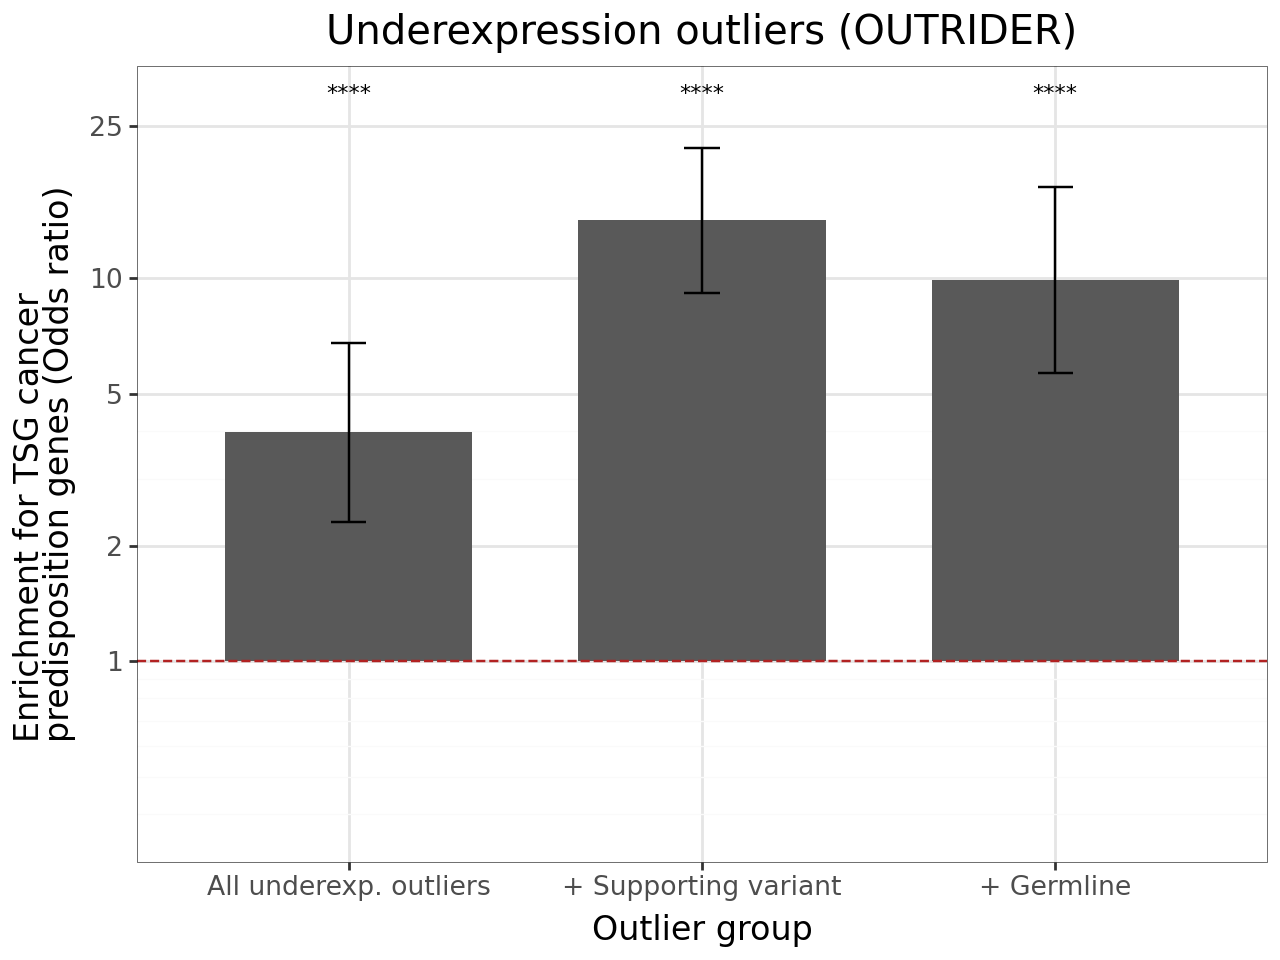

In [43]:
p_raw = (pn.ggplot(plot_df, pn.aes(x='group', y='odds_ratio')) +
    
    # Bars
    pn.geom_bar(stat='identity', position=pn.position_dodge(width=0.7), width=0.7) +
    
    # Text labels for "All"
    pn.geom_text(
        plot_df, 
        pn.aes(y=27, label='p_val_sign'),
        nudge_y=0.05,
        size=8
    ) +
     # Dashed horizontal line at y=1
    pn.geom_hline(yintercept=1, linetype='dashed', color='firebrick') +
    
    # Error bars
    pn.geom_errorbar(
        pn.aes(ymin='ci_min', ymax='ci_max'),
        width=0.1,
        position=pn.position_dodge(width=0.9)
    ) +
    
    # # Annotated text (totals)
    # pn.annotate(
    #     'text',
    #     x=plot_df['total_pos'],
    #     y=plot_df['total_height'] * 1.5,
    #     label=plot_df['total_label'],
    #     size=3
    # ) +
     # Log scale y-axis
    pn.scale_y_log10(
        breaks=[-0.2, -0.5, 1, 2, 5, 10, 25],
        minor_breaks=[i/10 for i in range(3,10)] + list(range(1,6))
    ) #+
    
    # Set cartesian limits
    # pn.coord_cartesian(
    #     ylim=(plot_df['ci_min'].min() - 0.01, 30),
    # )
)

p = (p_raw + 
    pn.labs(x='Outlier group', y = 'Enrichment for TSG cancer\npredisposition genes (Odds ratio)', title='Underexpression outliers (OUTRIDER)') +
    pn.theme_bw(base_size=12) +
    pn.theme(
        legend_position='top',
        legend_direction='vertical',
        panel_border=pn.element_rect(colour='black', fill=None, size=0.2)
    )
)
p


# Proteomics

In [4]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants.csv")
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all_protein_coding = pr_res_all[pr_res_all["gene_type_x"] == "protein_coding"]

In [5]:
expressed_proteins = pr_res_all_protein_coding["gene_id"].unique()
expressed_proteins

array(['ENSG00000204371.7', 'ENSG00000101752.7', 'ENSG00000166947.7', ...,
       'ENSG00000100982.7', 'ENSG00000215301.5', 'ENSG00000102837.6'],
      shape=(6759,), dtype=object)

In [6]:
# add 
protein_disrupting_variants = ["stop_gained", "missense_variant", "stop_lost", "splice_acceptor_variant", "splice_donor_variant", "frameshift_variant"]

pr_res_all_protein_coding["VUS_snv"] = False
pr_res_all_protein_coding["VUS_indel"] = False

mask_snv = (
    pr_res_all_protein_coding["Consequence_snv"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: bool(set(protein_disrupting_variants).intersection(x)))
)

mask_indel = (
    pr_res_all_protein_coding["Consequence_indel"]
    .fillna("")
    .str.split(",")
    .apply(lambda x: bool(set(protein_disrupting_variants).intersection(x)))
)

pr_res_all_protein_coding.loc[mask_snv, "VUS_snv"] = True
pr_res_all_protein_coding.loc[mask_indel, "VUS_indel"] = True
pr_res_all_protein_coding.loc[pr_res_all_protein_coding["IMPACT_snv"] == "HIGH", "VUS_snv"] = True
pr_res_all_protein_coding.loc[pr_res_all_protein_coding["IMPACT_indel"] == "HIGH", "VUS_indel"] = True


pr_res_all_protein_coding["VUS_promoterai_snv"] = False
pr_res_all_protein_coding.loc[pr_res_all_protein_coding["promoterAI_snv"] <= -0.1, "VUS_promoterai_snv"] = True


/tmp/ipykernel_2955054/3673455313.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2955054/3673455313.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2955054/3673455313.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [59]:
## target outliers: all underexpression ouliers
pr_all_under = pr_res_all_protein_coding[(pr_res_all_protein_coding["padjust"] <= 0.1) & (pr_res_all_protein_coding["zScore"] < 0) ]
pr_all_under_predisposition = pr_all_under[pr_all_under["predisposition_gene"] == True]
pr_all_under_predisposition_vus = pr_all_under_predisposition[((pr_all_under_predisposition["VUS_snv"] == True) | (pr_all_under_predisposition["VUS_promoterai_snv"] == True))  | (pr_all_under_predisposition["VUS_indel"] == True)]
pr_all_under_predisposition_vus_germline = pr_all_under_predisposition_vus[(((pr_all_under_predisposition_vus["VUS_snv"] == True) & (pr_all_under_predisposition_vus["ANNOTATION_control_snv"] == "germline")) |
        ((pr_all_under_predisposition_vus["ANNOTATION_control_indel"] == "germline") & (pr_all_under_predisposition_vus["VUS_indel"] == True)))]

In [60]:
print(pr_all_under.shape, "All protein underexpression outliers")
print(pr_all_under_predisposition.shape, "In predisposition genes")
print(pr_all_under_predisposition_vus.shape, "With supporting variant")
print(pr_all_under_predisposition_vus_germline.shape, "In germline variant")

(2882, 52) All protein underexpression outliers
(60, 52) In predisposition genes
(18, 52) With supporting variant
(8, 52) In germline variant


In [9]:
## DNA first approach
pr_all_under = pr_res_all_protein_coding[(pr_res_all_protein_coding["padjust_predisp"] <= 0.1) & (pr_res_all_protein_coding["zScore"] < 0) ]
pr_all_under_predisposition = pr_all_under[pr_all_under["predisposition_gene"] == True]
pr_all_under_predisposition_vus = pr_all_under_predisposition[((pr_all_under_predisposition["VUS_snv"] == True) | (pr_all_under_predisposition["VUS_promoterai_snv"] == True))  | (pr_all_under_predisposition["VUS_indel"] == True)]
pr_all_under_predisposition_vus_germline = pr_all_under_predisposition_vus[(((pr_all_under_predisposition_vus["VUS_snv"] == True) & (pr_all_under_predisposition_vus["ANNOTATION_control_snv"] == "germline")) |
        ((pr_all_under_predisposition_vus["ANNOTATION_control_indel"] == "germline") & (pr_all_under_predisposition_vus["VUS_indel"] == True)))]

In [10]:
print(pr_all_under_predisposition.shape, "In predisposition genes")
print(pr_all_under_predisposition_vus.shape, "With supporting variant")
print(pr_all_under_predisposition_vus_germline.shape, "In germline variant")

(138, 53) All protein underexpression outliers
(138, 53) In predisposition genes
(36, 53) With supporting variant
(13, 53) In germline variant


In [11]:
pr_all_under_predisposition_vus_germline

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [73]:
pr_res_all_protein_coding[(pr_res_all_protein_coding["VUS_promoterai_snv"] == True) & (pr_res_all_protein_coding["padjust"] <= 0.1) & (pr_res_all_protein_coding["VUS_snv"] != True) & (pr_res_all_protein_coding["VUS_indel"] != True)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [32]:
# 1️⃣ All outliers (gene-level)
all_outlier_proteins = (
    pr_res_all_protein_coding[(pr_res_all_protein_coding["padjust"] <= 0.1) & (pr_res_all_protein_coding["zScore"] < 0)]["gene_id"]
    .unique()
)

# 2️⃣ Variant-supported outliers
variant_supported_proteins = (
    pr_res_all_protein_coding
    .loc[(pr_res_all_protein_coding["padjust"] <= 0.1) & ((pr_res_all_protein_coding["VUS_snv"] == True) |  (pr_res_all_protein_coding["VUS_indel"] == True)) & (pr_res_all_protein_coding["zScore"] < 0), "gene_id"]
    .unique()
)

# 3️⃣ Germline-supported outliers
germline_supported_proteins = (
    pr_res_all_protein_coding
    .loc[
        (pr_res_all_protein_coding["padjust"] <= 0.1) & (pr_res_all_protein_coding["zScore"] < 0) &
        (((pr_res_all_protein_coding["VUS_snv"] == True) & (pr_res_all_protein_coding["ANNOTATION_control_snv"] == "germline")) |
        ((pr_res_all_protein_coding["ANNOTATION_control_indel"] == "germline") & (pr_res_all_protein_coding["VUS_indel"] == True)))
        ,
        "gene_id"
    ]
    .unique()
)
predisposition_genes = set(dresden_dt_tsg["geneID"])


In [33]:
rows = []

protein_groups = [
    ("All underexp. outliers", all_outlier_proteins),
    ("+ Supporting variant", variant_supported_proteins),
    ("+ Germline", germline_supported_proteins)
]

for label, proteins in protein_groups:
    or_val, ci_min, ci_max, p_val, a, b, c, d = fisher_enrichment(
        test_genes=proteins,
        background_genes=expressed_proteins,
        predisposition_genes=predisposition_genes
    )

    rows.append({
        "group": label,
        "subset_size": len(proteins),
        "odds_ratio": or_val,
        "ci_min": ci_min,
        "ci_max": ci_max,
        "p_val": p_val, 
        "p_val_sign": add_significance(p_val),
        "predisposition & group": a,
        "non-predisposition & group": b,
        "predisposition & background": c,
        "non-predispostion & background": d
        
    })

plot_df_protein = pd.DataFrame(rows)
category_order = ["All underexp. outliers", "+ Supporting variant", "+ Germline"]

# Make 'category' a categorical with the specified order
plot_df_protein['group'] = pd.Categorical(plot_df_protein['group'], categories=category_order, ordered=True)


In [34]:
plot_df_protein

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/mizani/transforms.py:378: RuntimeWarning: invalid value encountered in log10


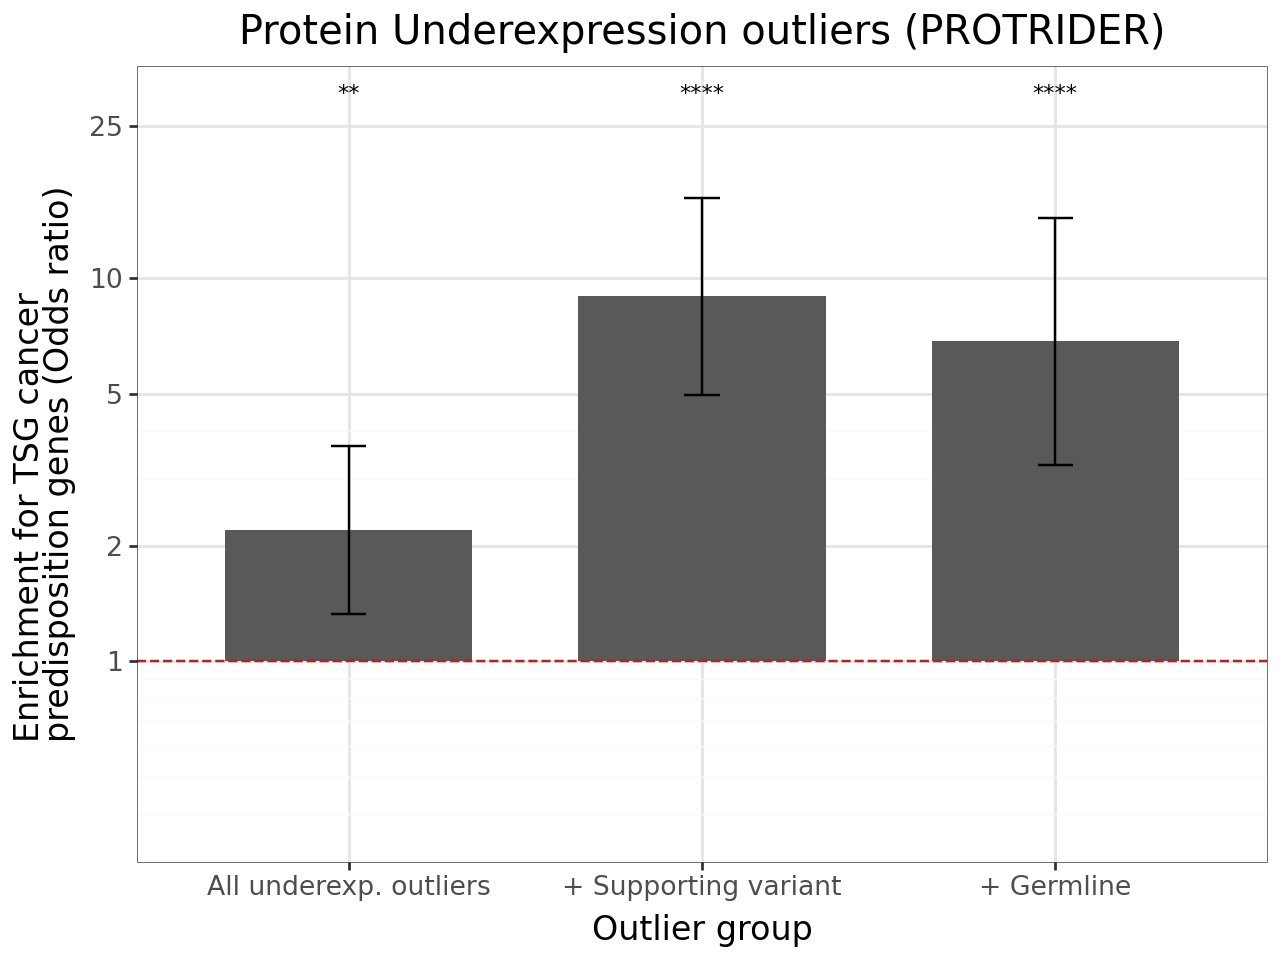

In [36]:
p_raw = (pn.ggplot(plot_df_protein, pn.aes(x='group', y='odds_ratio')) +
    
    # Bars
    pn.geom_bar(stat='identity', position=pn.position_dodge(width=0.7), width=0.7) +
    
    # Text labels for "All"
    pn.geom_text(
        plot_df_protein, 
        pn.aes(y=27, label='p_val_sign'),
        nudge_y=0.05,
        size=8
    ) +
     # Dashed horizontal line at y=1
    pn.geom_hline(yintercept=1, linetype='dashed', color='firebrick') +
    
    # Error bars
    pn.geom_errorbar(
        pn.aes(ymin='ci_min', ymax='ci_max'),
        width=0.1,
        position=pn.position_dodge(width=0.9)
    ) +
    
    # # Annotated text (totals)
    # pn.annotate(
    #     'text',
    #     x=plot_df['total_pos'],
    #     y=plot_df['total_height'] * 1.5,
    #     label=plot_df['total_label'],
    #     size=3
    # ) +
     # Log scale y-axis
    pn.scale_y_log10(
        breaks=[-0.2, -0.5, 1, 2, 5, 10, 25],
        minor_breaks=[i/10 for i in range(3,10)] + list(range(1,6))
    ) #+
    
    # Set cartesian limits
    # pn.coord_cartesian(
    #     ylim=(plot_df['ci_min'].min() - 0.01, 30),
    # )
)

p_protein = (p_raw + 
    pn.labs(x='Outlier group', y = 'Enrichment for TSG cancer\npredisposition genes (Odds ratio)', title='Protein Underexpression outliers (PROTRIDER)') +
    pn.theme_bw(base_size=12) +
    pn.theme(
        legend_position='top',
        legend_direction='vertical',
        panel_border=pn.element_rect(colour='black', fill=None, size=0.2)
    )
)
p_protein


# Splicing

In [6]:
fr_res = fr_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
fr_res = pd.merge(fr_res, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID_short", how="left")
fr_res = fr_res.merge(gene_annot_dt, left_on="geneID", right_on="gene_id", how="left")


In [74]:
fr_res["VUS_snv"] = False
fr_res["VUS_indel"] = False
fr_res.loc[fr_res["Consequence_snv"].str.contains("spli", na=False), "VUS_snv"] = True
fr_res.loc[fr_res["Consequence_indel"].str.contains("spli", na=False), "VUS_indel"] = True

fr_res["VUS_promoterai_snv"] = False
fr_res.loc[abs(fr_res["promoterAI_snv"]) >= 0.1, "VUS_promoterai_snv"] = True



In [75]:
fr_res_protein_coding = fr_res[fr_res["gene_type_y"] == "protein_coding"]
fr_res_protein_coding_predosposition = fr_res_protein_coding[fr_res_protein_coding["predisposition_gene"] == True]
fr_res_protein_coding_predosposition_vus = fr_res_protein_coding_predosposition[(fr_res_protein_coding_predosposition["VUS_snv"] == True) | (fr_res_protein_coding_predosposition["VUS_promoterai_snv"] == True) | (fr_res_protein_coding_predosposition["VUS_indel"] == True)]
fr_res_protein_coding_predosposition_vus_germline = fr_res_protein_coding_predosposition_vus[(((fr_res_protein_coding_predosposition_vus["VUS_snv"] == True) & (fr_res_protein_coding_predosposition_vus["ANNOTATION_control_snv"] == "germline")) |
        ((fr_res_protein_coding_predosposition_vus["ANNOTATION_control_indel"] == "germline") & (fr_res_protein_coding_predosposition_vus["VUS_indel"] == True)))]

In [76]:
print(fr_res_protein_coding.shape, "All protein underexpression outliers")
print(fr_res_protein_coding_predosposition.shape, "In predisposition genes")
print(fr_res_protein_coding_predosposition_vus.shape, "With supporting variant")
print(fr_res_protein_coding_predosposition_vus_germline.shape, "In germline variant")

(384390, 68) All protein underexpression outliers
(5146, 68) In predisposition genes
(328, 68) With supporting variant
(113, 68) In germline variant


In [85]:
fr_res_protein_coding_predosposition[((fr_res_protein_coding_predosposition["VUS_snv"] != True) & (fr_res_protein_coding_predosposition["VUS_indel"] != True)) & (fr_res_protein_coding_predosposition["VUS_promoterai_snv"] == True)] 

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [19]:
protein_coding_genes = gene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]

fr_expressed = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/datasets/savedObjects/aggregated_expressed_genes.tsv", sep="\t")

fr_expressed_protein_coding = fr_expressed.merge(protein_coding_genes, left_on="geneID", right_on="gene_id").geneID.values
fr_expressed_protein_coding

array(['ENSG00000237683.5', 'ENSG00000187634.6', 'ENSG00000188976.6', ...,
       'ENSG00000183678.8', 'ENSG00000184033.8', 'ENSG00000205944.7'],
      shape=(17017,), dtype=object)

In [20]:
# 1️⃣ All outliers (gene-level)
all_outlier_splicing = (
    fr_res_protein_coding["geneID"]
    .unique()
)

# 2️⃣ Variant-supported outliers
variant_supported_splicing = (
    fr_res_protein_coding
    .loc[((fr_res_protein_coding["VUS_snv"] == True) |  (fr_res_protein_coding["VUS_indel"] == True)), "gene_id"]
    .unique()
)

# 3️⃣ Germline-supported outliers
germline_supported_splicing = (
    fr_res_protein_coding
    .loc[
        (((fr_res_protein_coding["VUS_snv"] == True) & (fr_res_protein_coding["ANNOTATION_control_snv"] == "germline")) |
        ((fr_res_protein_coding["ANNOTATION_control_indel"] == "germline") & (fr_res_protein_coding["VUS_indel"] == True)))
        ,
        "gene_id"
    ]
    .unique()
)
predisposition_genes = set(dresden_dt_tsg["geneID"])


In [24]:
rows = []

splicing_groups = [
    ("All outliers", all_outlier_splicing),
    ("+ Supporting variant", variant_supported_splicing),
    ("+ Germline", germline_supported_splicing)
]

for label, genes in splicing_groups:
    or_val, ci_min, ci_max, p_val, a, b, c, d = fisher_enrichment(
        test_genes=genes,
        background_genes=fr_expressed_protein_coding,
        predisposition_genes=predisposition_genes
    )

    rows.append({
        "group": label,
        "subset_size": len(genes),
        "odds_ratio": or_val,
        "ci_min": ci_min,
        "ci_max": ci_max,
        "p_val": p_val, 
        "p_val_sign": add_significance(p_val),
        "predisposition & group": a,
        "non-predisposition & group": b,
        "predisposition & background": c,
        "non-predispostion & background": d
        
    })

plot_df_splicing = pd.DataFrame(rows)
category_order = ["All outliers", "+ Supporting variant", "+ Germline"]

# Make 'category' a categorical with the specified order
plot_df_splicing['group'] = pd.Categorical(plot_df_splicing['group'], categories=category_order, ordered=True)


In [26]:
plot_df_splicing

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/mizani/transforms.py:378: RuntimeWarning: invalid value encountered in log10


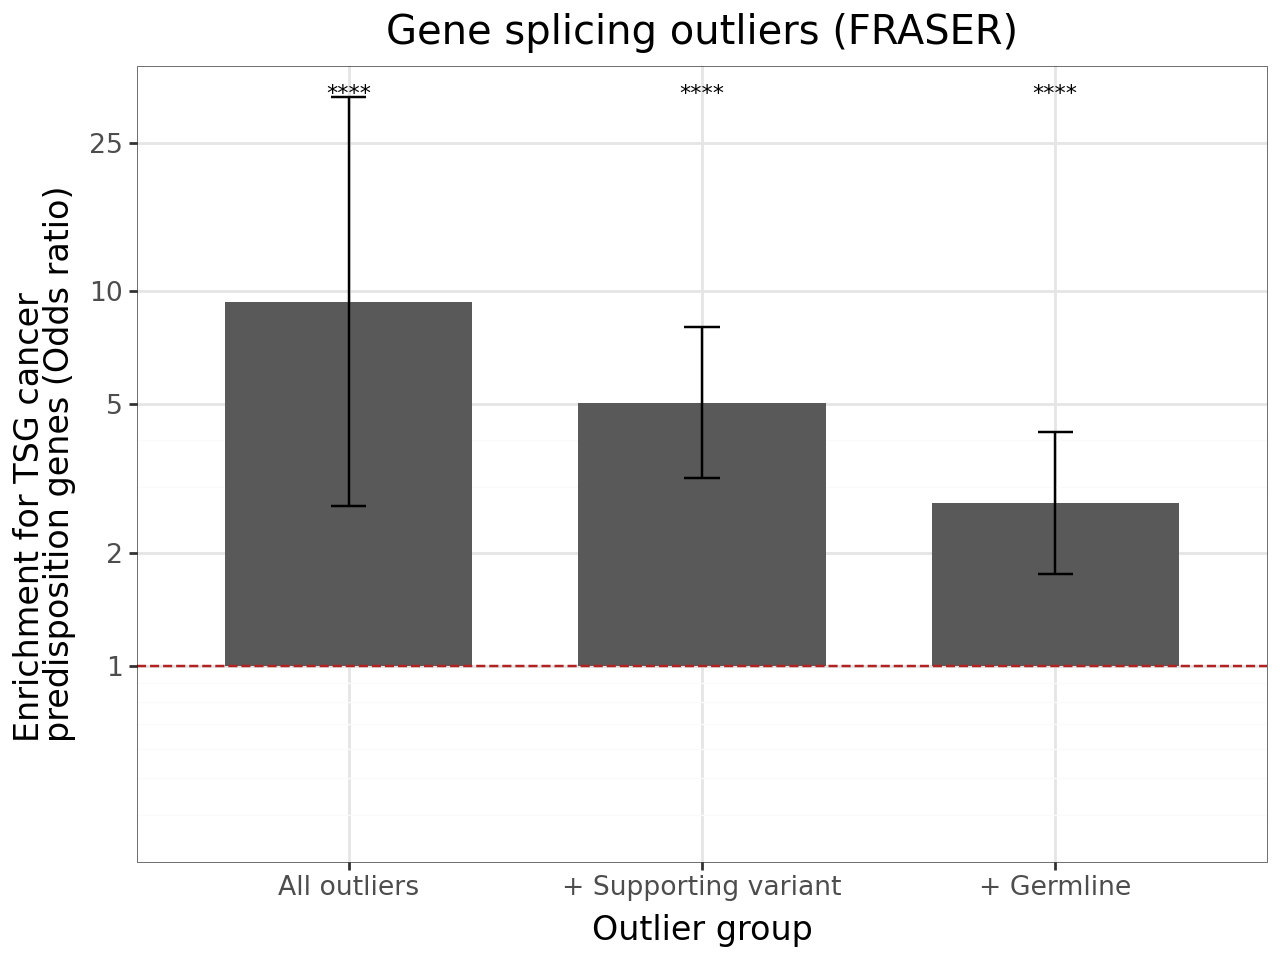

In [29]:
p_raw = (pn.ggplot(plot_df_splicing, pn.aes(x='group', y='odds_ratio')) +
    
    # Bars
    pn.geom_bar(stat='identity', position=pn.position_dodge(width=0.7), width=0.7) +
    
    # Text labels for "All"
    pn.geom_text(
        plot_df_splicing, 
        pn.aes(y=30, label='p_val_sign'),
        nudge_y=0.05,
        size=8
    ) +
     # Dashed horizontal line at y=1
    pn.geom_hline(yintercept=1, linetype='dashed', color='firebrick') +
    
    # Error bars
    pn.geom_errorbar(
        pn.aes(ymin='ci_min', ymax='ci_max'),
        width=0.1,
        position=pn.position_dodge(width=0.9)
    ) +
    
    # # Annotated text (totals)
    # pn.annotate(
    #     'text',
    #     x=plot_df['total_pos'],
    #     y=plot_df['total_height'] * 1.5,
    #     label=plot_df['total_label'],
    #     size=3
    # ) +
     # Log scale y-axis
    pn.scale_y_log10(
        breaks=[-0.2, -0.5, 1, 2, 5, 10, 25],
        minor_breaks=[i/10 for i in range(3,10)] + list(range(1,6))
    ) #+
    
    # Set cartesian limits
    # pn.coord_cartesian(
    #     ylim=(plot_df['ci_min'].min() - 0.01, 30),
    # )
)

p = (p_raw + 
    pn.labs(x='Outlier group', y = 'Enrichment for TSG cancer\npredisposition genes (Odds ratio)', title='Gene splicing outliers (FRASER)') +
    pn.theme_bw(base_size=12) +
    pn.theme(
        legend_position='top',
        legend_direction='vertical',
        panel_border=pn.element_rect(colour='black', fill=None, size=0.2)
    )
)
p
